In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
np.random.seed(42)
x = np.linspace(1, 10, 100)

a_real = 3.0
b_real = 2.0
ruido = np.random.normal(0, 1.5, size=len(x))

y = a_real + b_real * x + ruido

print(f"Se generaron {len(x)} puntos de datos.")

Se generaron 100 puntos de datos.


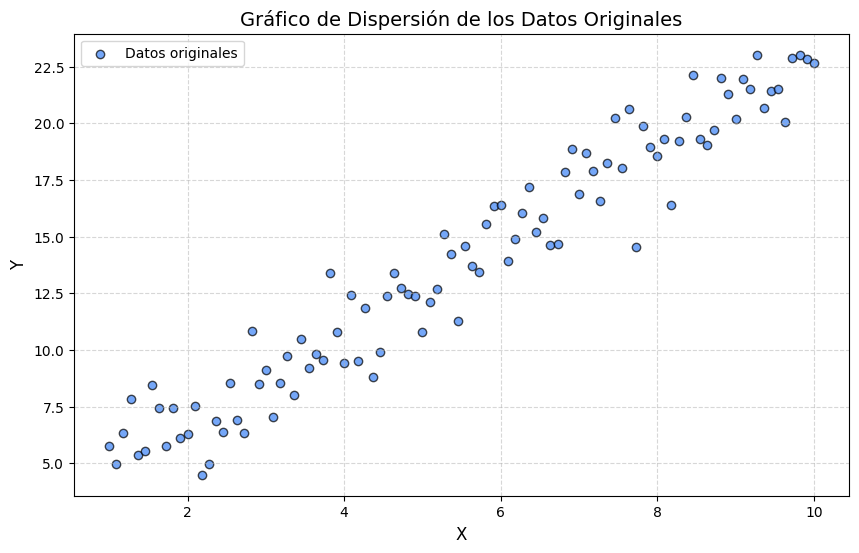

In [3]:
plt.figure(figsize=(10, 6))
plt.scatter(x, y, color='#3b82f6', alpha=0.7, edgecolors='k', label='Datos originales')
plt.title('Gráfico de Dispersión de los Datos Originales', fontsize=14)
plt.xlabel('X', fontsize=12)
plt.ylabel('Y', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

In [4]:
num_iteraciones = 15000
resultados = []

for i in range(num_iteraciones):
    a_rand = np.random.uniform(-10, 10)
    b_rand = np.random.uniform(-10, 10)

    acum = 0

    for j in range(len(x)):
        y_pred = a_rand + b_rand * x[j]
        error = abs(y[j] - y_pred)

        umbral = 0.10 * abs(y[j])
        if error < umbral:
            acum += 1

    resultados.append([acum, a_rand, b_rand])

resultados = np.array(resultados)

indice_mejor = np.argmax(resultados[:, 0])
mejor_acum, mejor_a, mejor_b = resultados[indice_mejor]

print("--- Búsqueda completada ---")
print(f"Mejor valor de a (intercepto): {mejor_a:.4f}")
print(f"Mejor valor de b (pendiente): {mejor_b:.4f}")
print(f"Cantidad de puntos con error < 10%: {int(mejor_acum)} de {len(x)}")

--- Búsqueda completada ---
Mejor valor de a (intercepto): 2.1849
Mejor valor de b (pendiente): 2.1900
Cantidad de puntos con error < 10%: 69 de 100


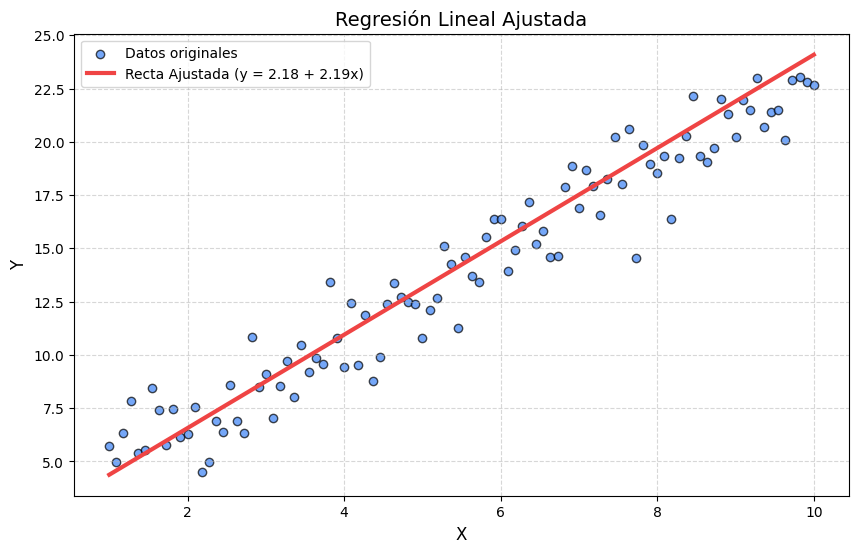

In [5]:
plt.figure(figsize=(10, 6))
plt.scatter(x, y, color='#3b82f6', alpha=0.7, edgecolors='k', label='Datos originales')

y_recta = mejor_a + mejor_b * x
plt.plot(x, y_recta, color='#ef4444', linewidth=3, label=f'Recta Ajustada (y = {mejor_a:.2f} + {mejor_b:.2f}x)')

plt.title('Regresión Lineal Ajustada', fontsize=14)
plt.xlabel('X', fontsize=12)
plt.ylabel('Y', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

In [6]:
x_nuevo = 12.5
y_prediccion = mejor_a + mejor_b * x_nuevo

print("--- Predicción ---")
print(f"Para un nuevo valor de X = {x_nuevo}, la predicción Y' es: {y_prediccion:.4f}")

--- Predicción ---
Para un nuevo valor de X = 12.5, la predicción Y' es: 29.5603
